## Visualizing Optical Flow From EXR
To run this notebook you first have to generate the `toy_dataset` which can be generated by executing `make toy_dataset`

In [5]:
import OpenEXR
import numpy as np
import Imath
import array
import cv2
import matplotlib.pyplot as plt
import json

### Optical Flow EXR to numpy array visualization
Thanks to [Tobias Weis](http://www.tobias-weis.de/groundtruth-data-for-computer-vision-with-blender/)

In [6]:
def exr2flow(exr, w, h):
    file = OpenEXR.InputFile(exr)

    # Compute the size
    dw = file.header()['dataWindow']
    sz = (dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1)

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    channels = file.header()['channels']

    def read_channel(component):
        channel = next(name for name in channels if name.endswith(f'.{component}'))
        return np.asarray(array.array('f', file.channel(channel, FLOAT)))

    # Blender 5 prefixes compositor EXR channels with the output item name.
    red = read_channel('R')
    green = read_channel('G')

    img = np.zeros((h, w, 3), np.float64)
    img[:, :, 0] = red.reshape(sz[1], sz[0])
    img[:, :, 1] = -green.reshape(sz[1], sz[0])

    hsv = np.zeros((h, w, 3), np.uint8)
    hsv[..., 1] = 255

    mag, ang = cv2.cartToPolar(img[..., 0], img[..., 1])
    hsv[..., 0] = ang*180/np.pi/2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return img, bgr, mag, ang

### Read the color image

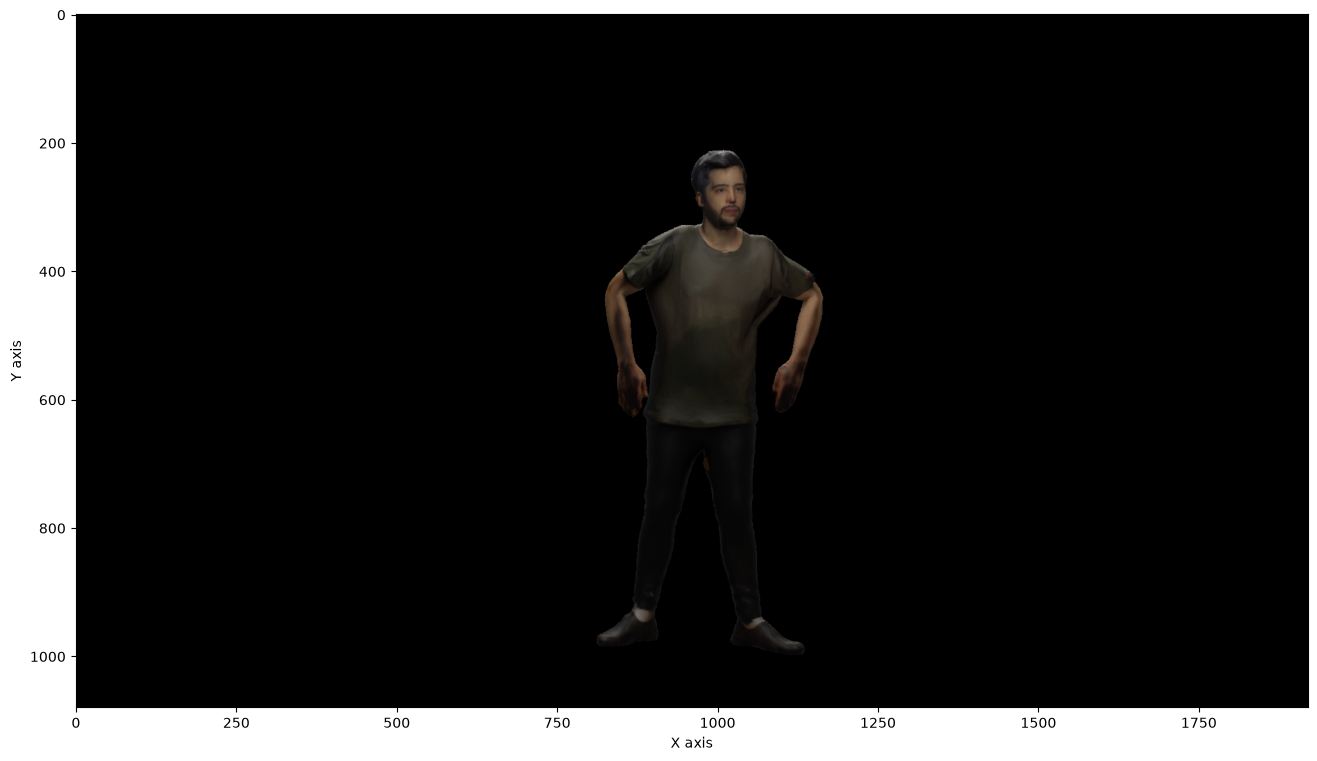

In [7]:
# The frame of the dataset we will use for visualization
FRAME_NUM = 3

# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Plot the color image
color = cv2.cvtColor(cv2.imread('../data/toy_dataset/color/Image{:0>4}.png'.format(FRAME_NUM)), cv2.COLOR_BGR2RGB)
ax.imshow(color)
plt.show()

### Read the depth EXR file
Depth values are in meters but in order to visualize them we normalize the range 0-5 meters

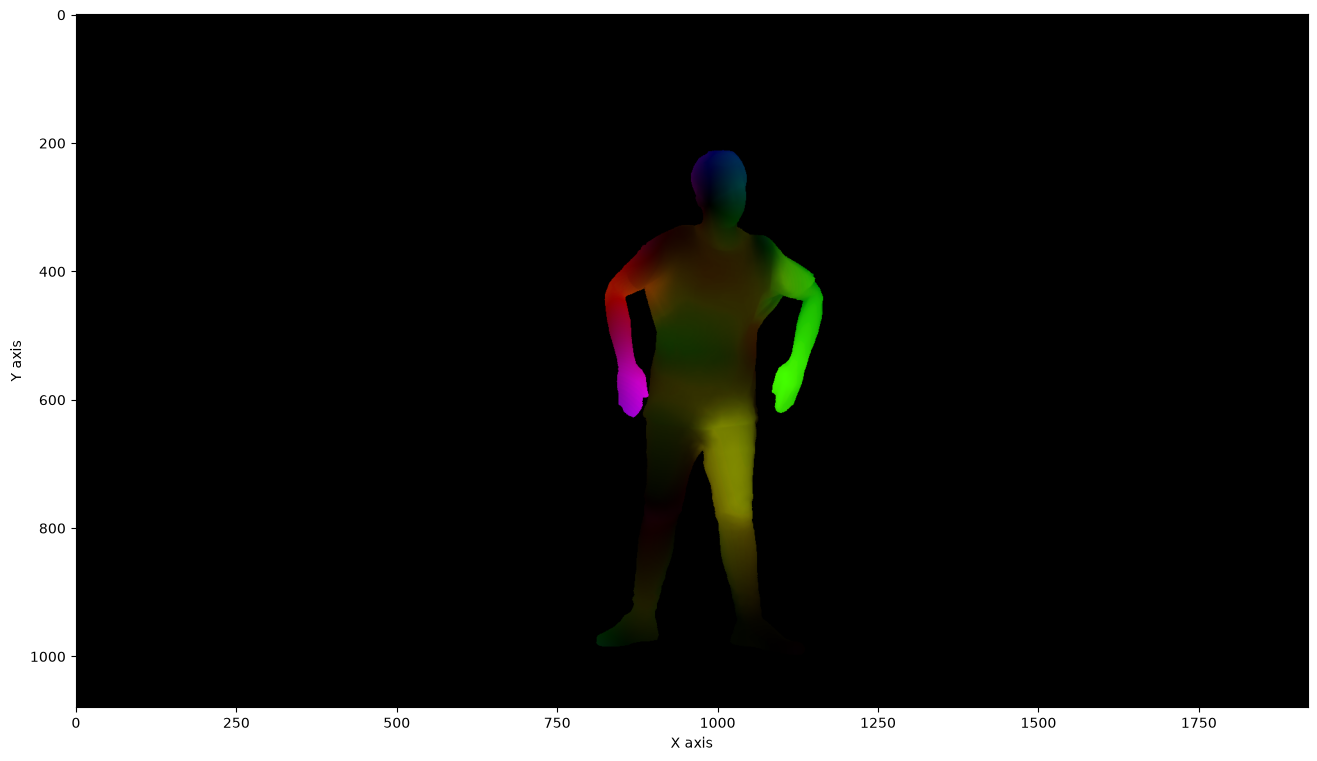

In [8]:
# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Draw the optical flow visualization
img, bgr, mag,ang = exr2flow('../data/toy_dataset/opticalflow/Image{:0>4}.exr'.format(FRAME_NUM), 1920, 1080)
ax.imshow(bgr)
plt.show()